In [12]:
!pip install scipy python-louvain networkx pandas matplotlib

  Using cached scipy-1.18.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached scipy-1.18.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)


In [13]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain  # pip install python-louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pd.set_option("display.max_columns", 10)

In [14]:
RAW_PATH = "Survey_Results_UC.csv"  # update path if needed

LIKERT_MAP = {
    "Strongly Disagree": -2,
    "Disagree": -1,
    "Neutral": 0,
    "Agree": 1,
    "Strongly Agree": 2,
    "No Comments": np.nan,
    "": np.nan,
}

def load_raw(path):
    df = pd.read_csv(path, encoding="utf-8-sig")
    df = df.set_index(df.columns[0])
    df.index.name = "respondent_id"
    return df

def build_question_meta(df):
    """Extract question code (T01..V15), domain, and question text from column headers."""
    meta = []
    for col in df.columns:
        code_ = col.split(".")[0].strip()
        text = col.split(".", 1)[1].strip() if "." in col else col
        domain = code_[0]  # T / E / S / V
        meta.append({"code": code_, "domain": domain, "text": text})
    return pd.DataFrame(meta)

def encode_numeric(df):
    q_meta = build_question_meta(df)
    numeric_df = df.copy()
    numeric_df.columns = q_meta["code"].values
    numeric_df = numeric_df.map(lambda x: LIKERT_MAP.get(x, np.nan) if isinstance(x, str) else np.nan)
    return numeric_df, q_meta

raw = load_raw(RAW_PATH)
numeric_df, q_meta = encode_numeric(raw)
q_meta = q_meta.set_index("code")

print(f"Respondents: {raw.shape[0]}, Questions: {raw.shape[1]}")
print(f"Total missing cells: {numeric_df.isna().sum().sum()} / {numeric_df.size} "
      f"({100*numeric_df.isna().sum().sum()/numeric_df.size:.2f}%)")
numeric_df.head()

Respondents: 96, Questions: 60
Total missing cells: 542 / 5760 (9.41%)


,T01,T02,T03,T04,T05,...,V11,V12,V13,V14,V15
respondent_id,,,,,,,,,,,
11,1.0,1.0,0.0,2.0,2.0,...,0.0,0.0,1.0,1.0,0.0
12,1.0,1.0,2.0,1.0,0.0,...,1.0,1.0,1.0,1.0,1.0
13,1.0,2.0,0.0,-1.0,2.0,...,2.0,1.0,2.0,2.0,1.0
14,0.0,1.0,0.0,1.0,1.0,...,1.0,1.0,2.0,2.0,1.0
16,0.0,1.0,2.0,2.0,-2.0,...,1.0,0.0,2.0,2.0,1.0


In [15]:
corr = numeric_df.corr(method="spearman")

def pairwise_n(df):
    mask = df.notna().astype(int)
    return mask.T.dot(mask)

n_obs = pairwise_n(numeric_df)

iu = np.triu_indices_from(corr.values, k=1)
offdiag = corr.values[iu]
print(f"{len(offdiag)} unique question pairs")
print(pd.Series(offdiag).describe())

for thresh in [0.30, 0.35, 0.40, 0.45, 0.50]:
    n_pos = (offdiag >= thresh).sum()
    n_neg = (offdiag <= -thresh).sum()
    print(f"|rho| >= {thresh}: {n_pos} positive, {n_neg} negative, {n_pos+n_neg} total edges")

1770 unique question pairs
count    1770.000000
mean        0.152632
std         0.158018
min        -0.404558
25%         0.049772
50%         0.153305
75%         0.262622
max         0.651526
dtype: float64
|rho| >= 0.3: 322 positive, 6 negative, 328 total edges
|rho| >= 0.35: 188 positive, 1 negative, 189 total edges
|rho| >= 0.4: 91 positive, 1 negative, 92 total edges
|rho| >= 0.45: 43 positive, 0 negative, 43 total edges
|rho| >= 0.5: 13 positive, 0 negative, 13 total edges


In [16]:
THRESHOLD = 0.40

G = nx.Graph()

# --- Nodes ---
for code_ in numeric_df.columns:
    col = numeric_df[code_]
    G.add_node(
        code_,
        domain=q_meta.loc[code_, "domain"],
        text=q_meta.loc[code_, "text"],
        mean=round(col.mean(), 3),
        variance=round(col.var(), 3),
        pct_neutral=round((col == 0).sum() / col.notna().sum(), 3),
        n_responses=int(col.notna().sum()),
    )

# --- Edges ---
codes = list(numeric_df.columns)
for i in range(len(codes)):
    for j in range(i + 1, len(codes)):
        a, b = codes[i], codes[j]
        rho = corr.loc[a, b]
        if abs(rho) >= THRESHOLD:
            G.add_edge(
                a, b,
                weight=round(float(rho), 3),
                abs_weight=round(abs(float(rho)), 3),
                sign="positive" if rho > 0 else "negative",
                n_pairs=int(n_obs.loc[a, b]),
            )

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Density: {nx.density(G):.4f}")

isolates = list(nx.isolates(G))
print(f"Isolated nodes: {len(isolates)} -> {isolates}")

deg = dict(G.degree())
top_deg = sorted(deg.items(), key=lambda x: -x[1])[:10]
print("\nTop 10 nodes by degree:")
for c, d in top_deg:
    node_domain = G.nodes[c]["domain"]
    node_text = G.nodes[c]["text"][:60]
    print(f"  {c} ({node_domain}): degree {d} -- {node_text}")

print("\nNegative edge(s):")
for u, v, d in G.edges(data=True):
    if d["sign"] == "negative":
        rho_val = d["weight"]
        n_val = d["n_pairs"]
        print(f"  {u} <-> {v}: rho={rho_val}, n={n_val}")

Graph: 60 nodes, 92 edges
Density: 0.0520
Isolated nodes: 17 -> ['T01', 'T03', 'T04', 'T05', 'T06', 'T07', 'T08', 'T09', 'T14', 'T15', 'E01', 'E02', 'E04', 'E08', 'E09', 'E13', 'S08']

Top 10 nodes by degree:
  V07 (V): degree 13 -- Protecting biodiversity is essential for long-term human wel
  S09 (S): degree 12 -- Universities should promote an inclusive environment where d
  V12 (V): degree 10 -- Environmental sustainability should be integrated into highe
  V10 (V): degree 9 -- Consumers should consider environmental impact when purchasi
  S14 (S): degree 8 -- Leaders should prioritize ethical decision-making even when 
  V08 (V): degree 8 -- Universities should adopt environmentally sustainable campus
  V06 (V): degree 7 -- Water conservation should be a priority in households, insti
  V09 (V): degree 7 -- Products should be designed to encourage reuse, repair, and 
  V14 (V): degree 7 -- International cooperation is necessary to effectively addres
  V15 (V): degree 7 -- Current g

In [17]:
partition = community_louvain.best_partition(G, weight="abs_weight", random_state=42)
nx.set_node_attributes(G, partition, "community")

modularity = community_louvain.modularity(partition, G, weight="abs_weight")
print(f"Communities: {len(set(partition.values()))}, Modularity: {modularity:.4f}")

df_comm = pd.DataFrame([
    {"code": n, "domain": G.nodes[n]["domain"], "community": c, "degree": G.degree(n)}
    for n, c in partition.items()
])

# Show only substantive communities (n >= 2); singletons are isolates
sizes = df_comm.groupby("community").size()
substantive = sizes[sizes >= 2].index
for c in sorted(substantive):
    members = df_comm[df_comm["community"] == c].sort_values("degree", ascending=False)
    codes_list = list(members["code"])
    print(f"\nCommunity {c} (n={len(members)}): {codes_list}")

Communities: 24, Modularity: 0.3801

Community 1 (n=4): ['S02', 'S03', 'S01', 'S04']

Community 9 (n=4): ['T12', 'T10', 'T13', 'S05']

Community 10 (n=12): ['S09', 'V12', 'V10', 'S14', 'V08', 'V03', 'S06', 'S13', 'S15', 'S07', 'V04', 'T11']

Community 16 (n=9): ['E15', 'E07', 'E12', 'E10', 'V01', 'V02', 'E14', 'T02', 'E03']

Community 18 (n=2): ['E05', 'E06']

Community 21 (n=2): ['S10', 'S12']

Community 23 (n=10): ['V07', 'V06', 'V14', 'V15', 'V09', 'V13', 'S11', 'E11', 'V05', 'V11']


In [18]:
for u, v, d in G.edges(data=True):
    d["distance"] = 1.0 / d["abs_weight"]

deg_c = nx.degree_centrality(G)
btw_c = nx.betweenness_centrality(G, weight="distance", normalized=True)

rows = []
for n in G.nodes():
    nbrs = list(G.neighbors(n))
    domain = G.nodes[n]["domain"]
    cross = [m for m in nbrs if G.nodes[m]["domain"] != domain]
    rows.append({
        "code": n, "domain": domain, "text": G.nodes[n]["text"],
        "degree": G.degree(n),
        "degree_centrality": round(deg_c[n], 4),
        "betweenness": round(btw_c[n], 4),
        "n_neighbors": len(nbrs),
        "pct_cross_domain": round(len(cross) / len(nbrs), 3) if nbrs else None,
        "community": G.nodes[n]["community"],
    })
centrality_df = pd.DataFrame(rows)

print("=== Top 10 hubs (degree) ===")
display(centrality_df.sort_values("degree_centrality", ascending=False)
        [["code", "domain", "degree", "text"]].head(10))

print("\n=== Top 10 bridges (betweenness) ===")
display(centrality_df.sort_values("betweenness", ascending=False)
        [["code", "domain", "betweenness", "pct_cross_domain", "text"]].head(10))

print("\n=== Divisive keystone(s): nodes on the negative edge ===")
neg_nodes = {u for u, v, d in G.edges(data=True) if d["sign"] == "negative"} | \
            {v for u, v, d in G.edges(data=True) if d["sign"] == "negative"}
display(centrality_df[centrality_df["code"].isin(neg_nodes)]
        [["code", "domain", "degree", "betweenness", "text"]])

=== Top 10 hubs (degree) ===


,code,domain,degree,text
51,V07,V,13,Protecting biodiversity is essential for long-...
38,S09,S,12,Universities should promote an inclusive envir...
56,V12,V,10,Environmental sustainability should be integra...
54,V10,V,9,Consumers should consider environmental impact...
43,S14,S,8,Leaders should prioritize ethical decision-mak...
52,V08,V,8,Universities should adopt environmentally sust...
53,V09,V,7,Products should be designed to encourage reuse...
50,V06,V,7,Water conservation should be a priority in hou...
58,V14,V,7,International cooperation is necessary to effe...
59,V15,V,7,Current generations have a responsibility to p...



=== Top 10 bridges (betweenness) ===


,code,domain,betweenness,pct_cross_domain,text
42,S13,S,0.0859,0.600,Critical evaluation of online information shou...
38,S09,S,0.0842,0.417,Universities should promote an inclusive envir...
51,V07,V,0.0830,0.308,Protecting biodiversity is essential for long-...
54,V10,V,0.0725,0.556,Consumers should consider environmental impact...
21,E07,E,0.0713,0.600,Publishing research before graduation should b...
11,T12,T,0.0660,0.333,Governments should introduce stricter regulati...
43,S14,S,0.0608,0.500,Leaders should prioritize ethical decision-mak...
59,V15,V,0.0544,0.286,Current generations have a responsibility to p...
52,V08,V,0.0444,0.250,Universities should adopt environmentally sust...
29,E15,E,0.0432,0.500,Continuous learning and skill development are ...



=== Divisive keystone(s): nodes on the negative edge ===


,code,domain,degree,betweenness,text
17,E03,E,1,0.000,Class attendance should be compulsory for all ...
24,E10,E,3,0.024,Universities should prioritize innovation and ...


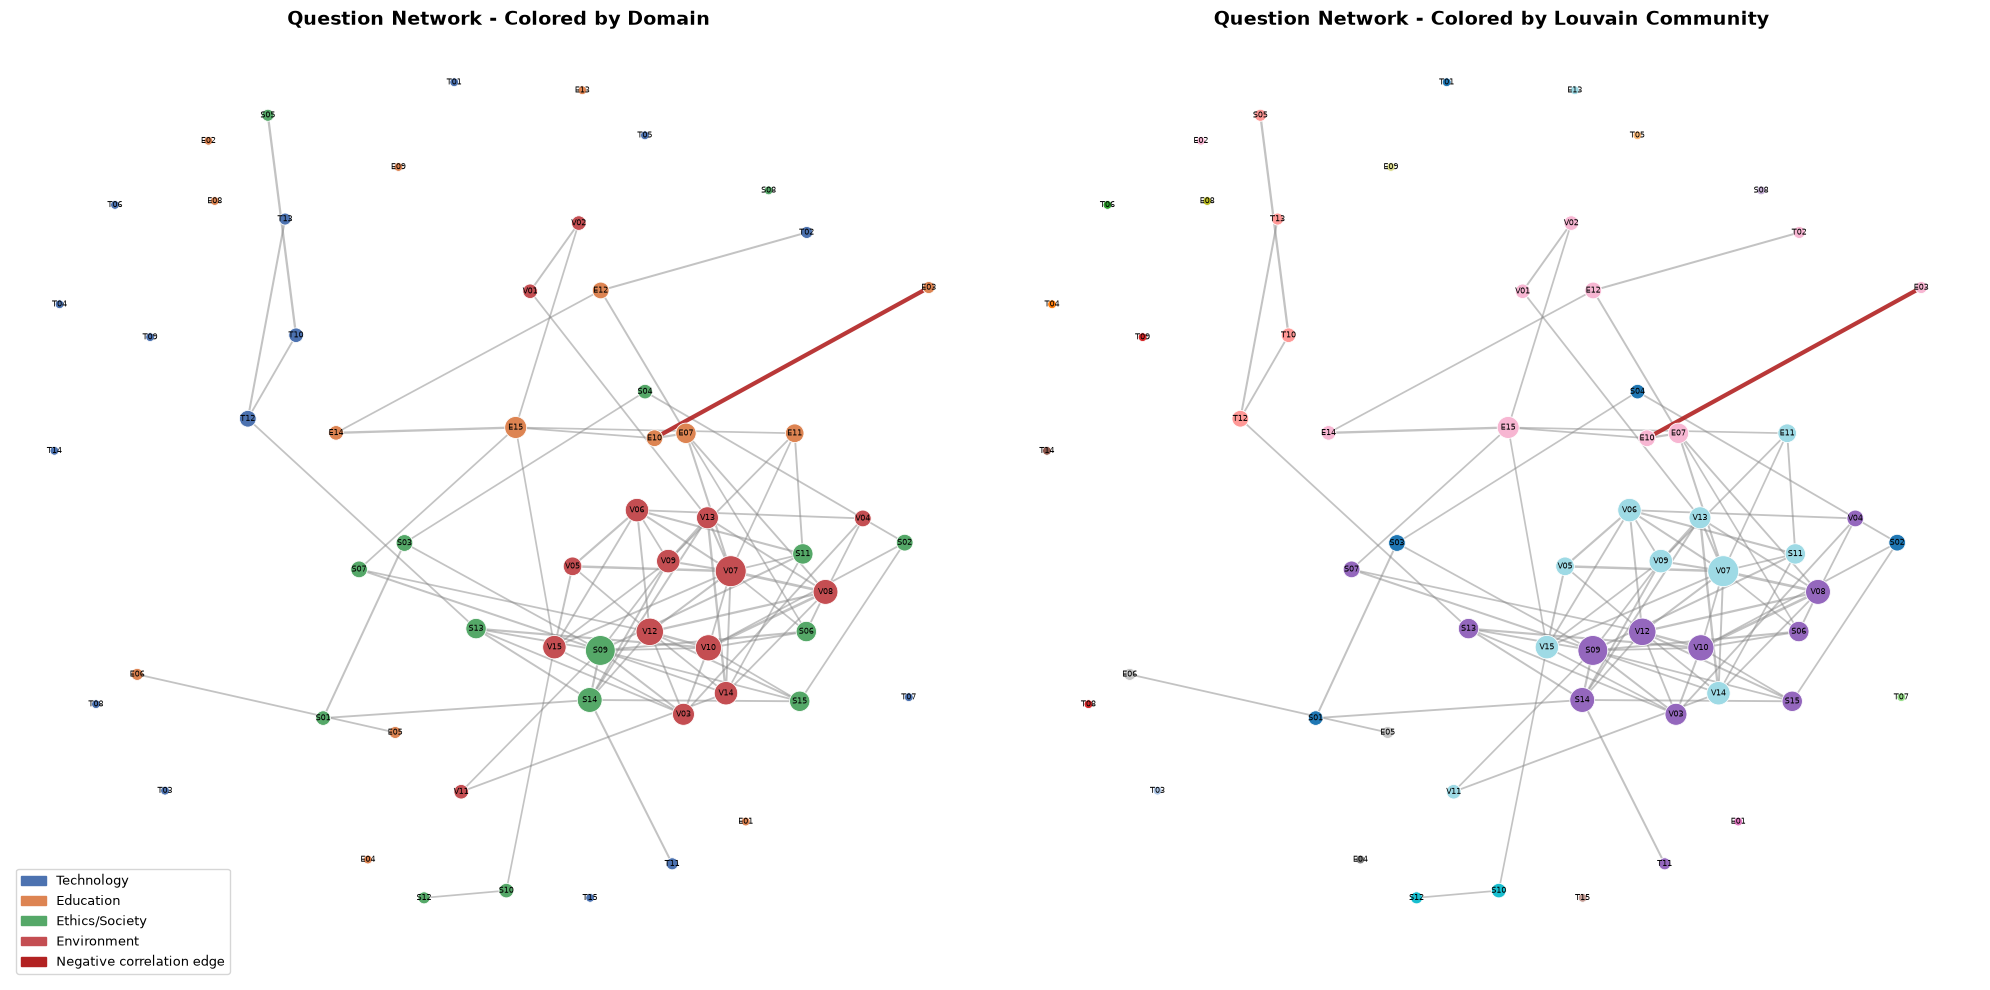

In [19]:
pos = nx.spring_layout(G, k=0.5, seed=42, weight="abs_weight")

DOMAIN_COLORS = {"T": "#4C72B0", "E": "#DD8452", "S": "#55A868", "V": "#C44E52"}
DOMAIN_LABELS = {"T": "Technology", "E": "Education", "S": "Ethics/Society", "V": "Environment"}

communities = sorted(set(nx.get_node_attributes(G, "community").values()))
cmap = plt.colormaps.get_cmap("tab20")
COMMUNITY_COLORS = {c: cmap(i / max(len(communities) - 1, 1)) for i, c in enumerate(communities)}

def node_sizes(G, base=40, scale=35):
    return [base + scale * G.degree(n) for n in G.nodes()]

def draw_edges(ax, G, pos):
    pos_edges = [(u, v) for u, v, d in G.edges(data=True) if d["sign"] == "positive"]
    neg_edges = [(u, v) for u, v, d in G.edges(data=True) if d["sign"] == "negative"]
    nx.draw_networkx_edges(G, pos, edgelist=pos_edges,
                            width=[G[u][v]["abs_weight"] * 3 for u, v in pos_edges],
                            edge_color="#888888", alpha=0.5, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=neg_edges,
                            width=[G[u][v]["abs_weight"] * 7.5 for u, v in neg_edges],
                            edge_color="#B22222", alpha=0.9, ax=ax)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

ax = axes[0]
draw_edges(ax, G, pos)
nx.draw_networkx_nodes(G, pos, node_color=[DOMAIN_COLORS[G.nodes[n]["domain"]] for n in G.nodes()],
                        node_size=node_sizes(G), edgecolors="white", linewidths=0.6, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)
ax.set_title("Question Network - Colored by Domain", fontsize=14, fontweight="bold")
ax.axis("off")
handles = [mpatches.Patch(color=c, label=DOMAIN_LABELS[k]) for k, c in DOMAIN_COLORS.items()]
handles.append(mpatches.Patch(color="#B22222", label="Negative correlation edge"))
ax.legend(handles=handles, loc="lower left", fontsize=9, frameon=True)

ax = axes[1]
draw_edges(ax, G, pos)
nx.draw_networkx_nodes(G, pos, node_color=[COMMUNITY_COLORS[G.nodes[n]["community"]] for n in G.nodes()],
                        node_size=node_sizes(G), edgecolors="white", linewidths=0.6, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)
ax.set_title("Question Network - Colored by Louvain Community", fontsize=14, fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.savefig("network_visualization.png", dpi=200, bbox_inches="tight")
plt.show()

In [20]:
nx.write_gexf(G, "question_network.gexf")  # for Gephi, if needed
centrality_df.to_csv("centrality_metrics.csv", index=False)
df_comm.to_csv("communities.csv", index=False)
corr.to_csv("spearman_corr.csv")
print("Saved: question_network.gexf, centrality_metrics.csv, communities.csv, spearman_corr.csv")

Saved: question_network.gexf, centrality_metrics.csv, communities.csv, spearman_corr.csv


In [21]:
import community as community_louvain

codes = list(corr.columns)
results = []
for thresh in [0.30, 0.35, 0.40, 0.45, 0.50]:
    Gt = nx.Graph()
    Gt.add_nodes_from(codes)
    for i in range(len(codes)):
        for j in range(i + 1, len(codes)):
            rho = corr.iloc[i, j]
            if abs(rho) >= thresh:
                Gt.add_edge(codes[i], codes[j], weight=abs(rho))
    part = community_louvain.best_partition(Gt, weight="weight", random_state=42) if Gt.number_of_edges() > 0 else {}
    mod = community_louvain.modularity(part, Gt, weight="weight") if part else np.nan
    n_comm = len(set(part.values())) if part else 0
    n_iso = len(list(nx.isolates(Gt)))
    n_substantive = sum(1 for c in set(part.values()) if list(part.values()).count(c) >= 2) if part else 0
    results.append({
        "threshold": thresh, "edges": Gt.number_of_edges(), "isolates": n_iso,
        "n_communities": n_comm, "substantive_communities": n_substantive,
        "modularity": round(mod, 4) if mod == mod else None,
    })

sens_df = pd.DataFrame(results)
print("=== THRESHOLD SENSITIVITY ===")
display(sens_df)
sens_df.to_csv("threshold_sensitivity.csv", index=False)

=== THRESHOLD SENSITIVITY ===


,threshold,edges,isolates,n_communities,substantive_communities,modularity
0,0.30,328,3,7,4,0.2522
1,0.35,189,12,17,5,0.3222
2,0.40,92,17,24,7,0.3801
3,0.45,43,26,35,9,0.5154
4,0.50,13,42,49,7,0.7008


In [22]:
# --- Domain assortativity ---
r = nx.attribute_assortativity_coefficient(G, "domain")
print(f"Domain assortativity coefficient: {r:.4f}")
print("(+1 = edges only within same domain, 0 = random mixing, -1 = only cross-domain)\n")

same, cross = 0, 0
for u, v in G.edges():
    if G.nodes[u]["domain"] == G.nodes[v]["domain"]:
        same += 1
    else:
        cross += 1
total = same + cross
print(f"Same-domain edges: {same} ({100*same/total:.1f}%) | Cross-domain edges: {cross} ({100*cross/total:.1f}%)")

# --- Consensus vs. controversial questions ---
rows = []
for n, d in G.nodes(data=True):
    rows.append({
        "code": n, "domain": d["domain"], "text": d["text"],
        "mean": d["mean"], "variance": d["variance"],
        "pct_neutral": d["pct_neutral"], "degree": G.degree(n),
    })
attr_df = pd.DataFrame(rows)

print("\n=== Top 8 MOST CONSENSUAL (lowest variance) ===")
display(attr_df.sort_values("variance").head(8)[["code", "domain", "mean", "variance", "text"]])

print("\n=== Top 8 MOST CONTROVERSIAL (highest variance) ===")
display(attr_df.sort_values("variance", ascending=False).head(8)[["code", "domain", "mean", "variance", "text"]])

corr_var_deg = attr_df["variance"].corr(attr_df["degree"], method="spearman")
print(f"\nSpearman corr(variance, degree) = {corr_var_deg:.3f}")
print("(negative -> low-variance/consensual questions tend to be network hubs)")

attr_df.to_csv("consensus_controversy.csv", index=False)

# --- Wider view of negative correlations (threshold 0.30) for the E03 discussion ---
neg_pairs = []
for i in range(len(codes)):
    for j in range(i + 1, len(codes)):
        rho = corr.iloc[i, j]
        if rho <= -0.30:
            neg_pairs.append({"q1": codes[i], "q2": codes[j], "rho": round(float(rho), 3)})
neg_df = pd.DataFrame(neg_pairs).sort_values("rho")
print("\n=== All negative correlations >= 0.30 ===")
display(neg_df)
neg_df.to_csv("negative_pairs_030.csv", index=False)

Domain assortativity coefficient: 0.4103
(+1 = edges only within same domain, 0 = random mixing, -1 = only cross-domain)

Same-domain edges: 58 (63.0%) | Cross-domain edges: 34 (37.0%)

=== Top 8 MOST CONSENSUAL (lowest variance) ===


,code,domain,mean,variance,text
29,E15,E,1.713,0.254,Continuous learning and skill development are ...
57,V13,V,1.671,0.319,Companies should be held accountable for the e...
38,S09,S,1.471,0.347,Universities should promote an inclusive envir...
50,V06,V,1.512,0.349,Water conservation should be a priority in hou...
34,S05,S,1.632,0.352,Individuals should have greater control over h...
40,S11,S,1.552,0.366,People should be free to express differing opi...
59,V15,V,1.506,0.396,Current generations have a responsibility to p...
45,V01,V,1.518,0.396,Climate change requires immediate global action.



=== Top 8 MOST CONTROVERSIAL (highest variance) ===


,code,domain,mean,variance,text
18,E04,E,0.437,1.365,High-quality online learning can effectively c...
17,E03,E,-0.943,1.264,Class attendance should be compulsory for all ...
16,E02,E,-0.161,1.253,Traditional written examinations accurately me...
7,T08,T,0.078,1.196,AI-assisted diagnosis should become routine in...
31,S02,S,0.839,1.113,Universities should encourage students to part...
23,E09,E,0.791,1.085,Collaborative learning is generally more effec...
6,T07,T,1.209,1.078,Robots should replace humans in hazardous occu...
26,E12,E,0.931,1.065,Artificial intelligence should be integrated i...



Spearman corr(variance, degree) = -0.559
(negative -> low-variance/consensual questions tend to be network hubs)

=== All negative correlations >= 0.30 ===


,q1,q2,rho
3,E03,E10,-0.405
4,E03,E11,-0.346
0,T03,E04,-0.333
2,E01,E02,-0.328
1,T14,E03,-0.313
5,E03,E12,-0.305
